# Задача
В этой работе вам предлагается решить задачу бинарной классификации, а именно построить алгоритм, определяющий превысит ли средний заработок человека порог $50k. Каждый объект выборки — человек, для которого известны следующие признаки:
 - age
 - workclass
 - fnlwgt
 - education
 - education-num
 - marital-status
 - occupation
 - relationship
 - race
 - sex
 - capital-gain
 - capital-loss
 - hours-per-week
 
Более подробно про признаки можно почитать [здесь](http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names). Целевой признак записан в переменной *>50K,<=50K*.

В этой задаче для обучения будут использовать 2 алгоритма:
 - [DecisonTree](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)
 - [RandomForest](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

# Решение

Загрузите набор данных *data.adult.csv* с помощью `pandas` (скачать можно [здесь](https://drive.google.com/file/d/1Lo47fXx1RrJG3v9E-Gck1T45n5bJ_SJf/view?usp=sharing), или с помощью скрипта ниже). Чтобы лучше понимать, с чем вы работаете/корректно ли вы загрузили данные можно вывести несколько первых строк на экран.

In [ ]:
!gdown 1Lo47fXx1RrJG3v9E-Gck1T45n5bJ_SJf

Downloading...
From: https://drive.google.com/uc?id=1Lo47fXx1RrJG3v9E-Gck1T45n5bJ_SJf
To: /content/data.adult.csv
100% 1.54M/1.54M [00:00<00:00, 141MB/s]


In [358]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report


In [206]:
# your code here
data = pd.read_csv('data.adult.csv')
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,">50K,<=50K"
0,34,Local-gov,284843,HS-grad,9,Never-married,Farming-fishing,Not-in-family,Black,Male,594,0,60,<=50K
1,40,Private,190290,Some-college,10,Divorced,Sales,Not-in-family,White,Male,0,0,40,<=50K
2,36,Local-gov,177858,Bachelors,13,Married-civ-spouse,Prof-specialty,Own-child,White,Male,0,0,40,<=50K
3,22,Private,184756,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,<=50K
4,47,Private,149700,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,15024,0,40,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,25,Local-gov,514716,Bachelors,13,Never-married,Adm-clerical,Own-child,Black,Female,0,0,40,<=50K
16276,32,Private,207668,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,15024,0,45,>50K
16277,27,Private,104457,Bachelors,13,Never-married,Machine-op-inspct,Not-in-family,Asian-Pac-Islander,Male,0,0,40,<=50K
16278,59,State-gov,268700,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,<=50K


## Анализ и предобработка данных

Обычно после загрузки датасета всегда необходима его некоторая предобработка. В данном случае она будет заключаться в следующем: 
1. Проверьте есть ли в данных пропущенные значения (здесь они обозначены как "?"). Удалите из выборки все объекты с пропусками.
2. Выделите 60% выборки для обучения и дальнейшего анализа.
3. Обратите внимание, что не все признаки являются вещественными (числовыми). Сначала их необходимо проанализировать и по необходимости предобработать. Все шаги предобработки поясните текстом.
4. Целевую переменную (ту, которую мы хотим предсказывать) можно выделить в отдельную переменную и преобразуйте к бинарному формату (НЕ забудьте удалить ее из датасета, когда будете обучать модель).


In [207]:
# удаление NaN и '?'
data_with_na = data.loc[(data['age'] == '?') 
    | (data['workclass'] == '?')
    | (data['fnlwgt'] == '?') 
    | (data['education'] == '?') 
    | (data['education-num'] == '?') 
    | (data['marital-status'] == '?') 
    | (data['occupation'] == '?') 
    | (data['relationship'] == '?') 
    | (data['race'] == '?') 
    | (data['sex'] == '?')
    | (data['capital-gain'] == '?')
    | (data['capital-loss'] == '?')
    | (data['hours-per-week'] == '?')
    | (data['>50K,<=50K'] == '?')]

print(f"objects with NA in data: {data_with_na.shape[0]}")

data.drop(data_with_na.index, inplace=True)

objects with NA in data: 933


In [208]:
# Разделение на трейн и тест
X = data.drop(['>50K,<=50K'], axis=1)
y = data['>50K,<=50K']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)

In [209]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9208 entries, 7468 to 7736
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             9208 non-null   int64 
 1   workclass       9208 non-null   object
 2   fnlwgt          9208 non-null   int64 
 3   education       9208 non-null   object
 4   education-num   9208 non-null   int64 
 5   marital-status  9208 non-null   object
 6   occupation      9208 non-null   object
 7   relationship    9208 non-null   object
 8   race            9208 non-null   object
 9   sex             9208 non-null   object
 10  capital-gain    9208 non-null   int64 
 11  capital-loss    9208 non-null   int64 
 12  hours-per-week  9208 non-null   int64 
dtypes: int64(6), object(7)
memory usage: 1007.1+ KB


In [210]:
# Рассмотрение уникальных значений в категориальных признаках
for column in X_train.columns:
    if X_train[column].dtype == 'O':
        print(f"{column}:{X_train[column].unique()}", '\n')

workclass:['Self-emp-not-inc' 'State-gov' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay'] 

education:['Masters' 'Some-college' '10th' 'HS-grad' 'Assoc-acdm' 'Assoc-voc'
 'Bachelors' '9th' 'Prof-school' '11th' 'Doctorate' '12th' '5th-6th'
 '7th-8th' '1st-4th' 'Preschool'] 

marital-status:['Married-civ-spouse' 'Divorced' 'Never-married' 'Separated' 'Widowed'
 'Married-spouse-absent' 'Married-AF-spouse'] 

occupation:['Exec-managerial' 'Adm-clerical' 'Other-service' 'Sales' 'Craft-repair'
 'Prof-specialty' 'Tech-support' 'Machine-op-inspct' 'Handlers-cleaners'
 'Transport-moving' 'Protective-serv' 'Farming-fishing' 'Priv-house-serv'
 'Armed-Forces'] 

relationship:['Husband' 'Not-in-family' 'Own-child' 'Unmarried' 'Wife' 'Other-relative'] 

race:['White' 'Amer-Indian-Eskimo' 'Black' 'Asian-Pac-Islander' 'Other'] 

sex:['Male' 'Female'] 



**Столбец education задает уровень образования, однако есть столбец education-num с продолжительностью образования - есть предположение, что каждому уровню образования относится одна уникальная продолжительность образования.**

In [211]:
for num in data['education'].value_counts().keys():
    print(f"{num}: {data.loc[data['education'] == num, 'education-num'].unique()}")

HS-grad: [9]
Some-college: [10]
Bachelors: [13]
Masters: [14]
Assoc-voc: [11]
11th: [7]
Assoc-acdm: [12]
10th: [6]
Prof-school: [15]
7th-8th: [4]
9th: [5]
Doctorate: [16]
12th: [8]
5th-6th: [3]
1st-4th: [2]
Preschool: [1]


**Предположение подтверилось, поэтому особого смысла держать два столюца нет.**
**В остальном нет явных идей по преобразованию категориальных признаков помимо энкодинга.**

In [212]:
X_train.drop(['education'], axis=1, inplace=True)
X_test.drop(['education'], axis=1, inplace=True)

In [213]:
# Перевод целевого признака в бинарную систему
le = LabelEncoder()
y_test = le.fit_transform(y_test)
y_train = le.transform(y_train)
y_train

array([1, 0, 0, ..., 0, 0, 0])

При обучении алгоритмов стоит обращать внимание не только на их качество, но и каким образом они работают с данными. Давайте посмотрим на значения самих признаков.

Что можете сказать о разбросе данных и сбалансированности выборки? В каком диапазоне лежат исследуемые признаки?

In [214]:
# Удаление столбца education, потому что не интересует его распределение
data.drop('education', axis=1,inplace=True)

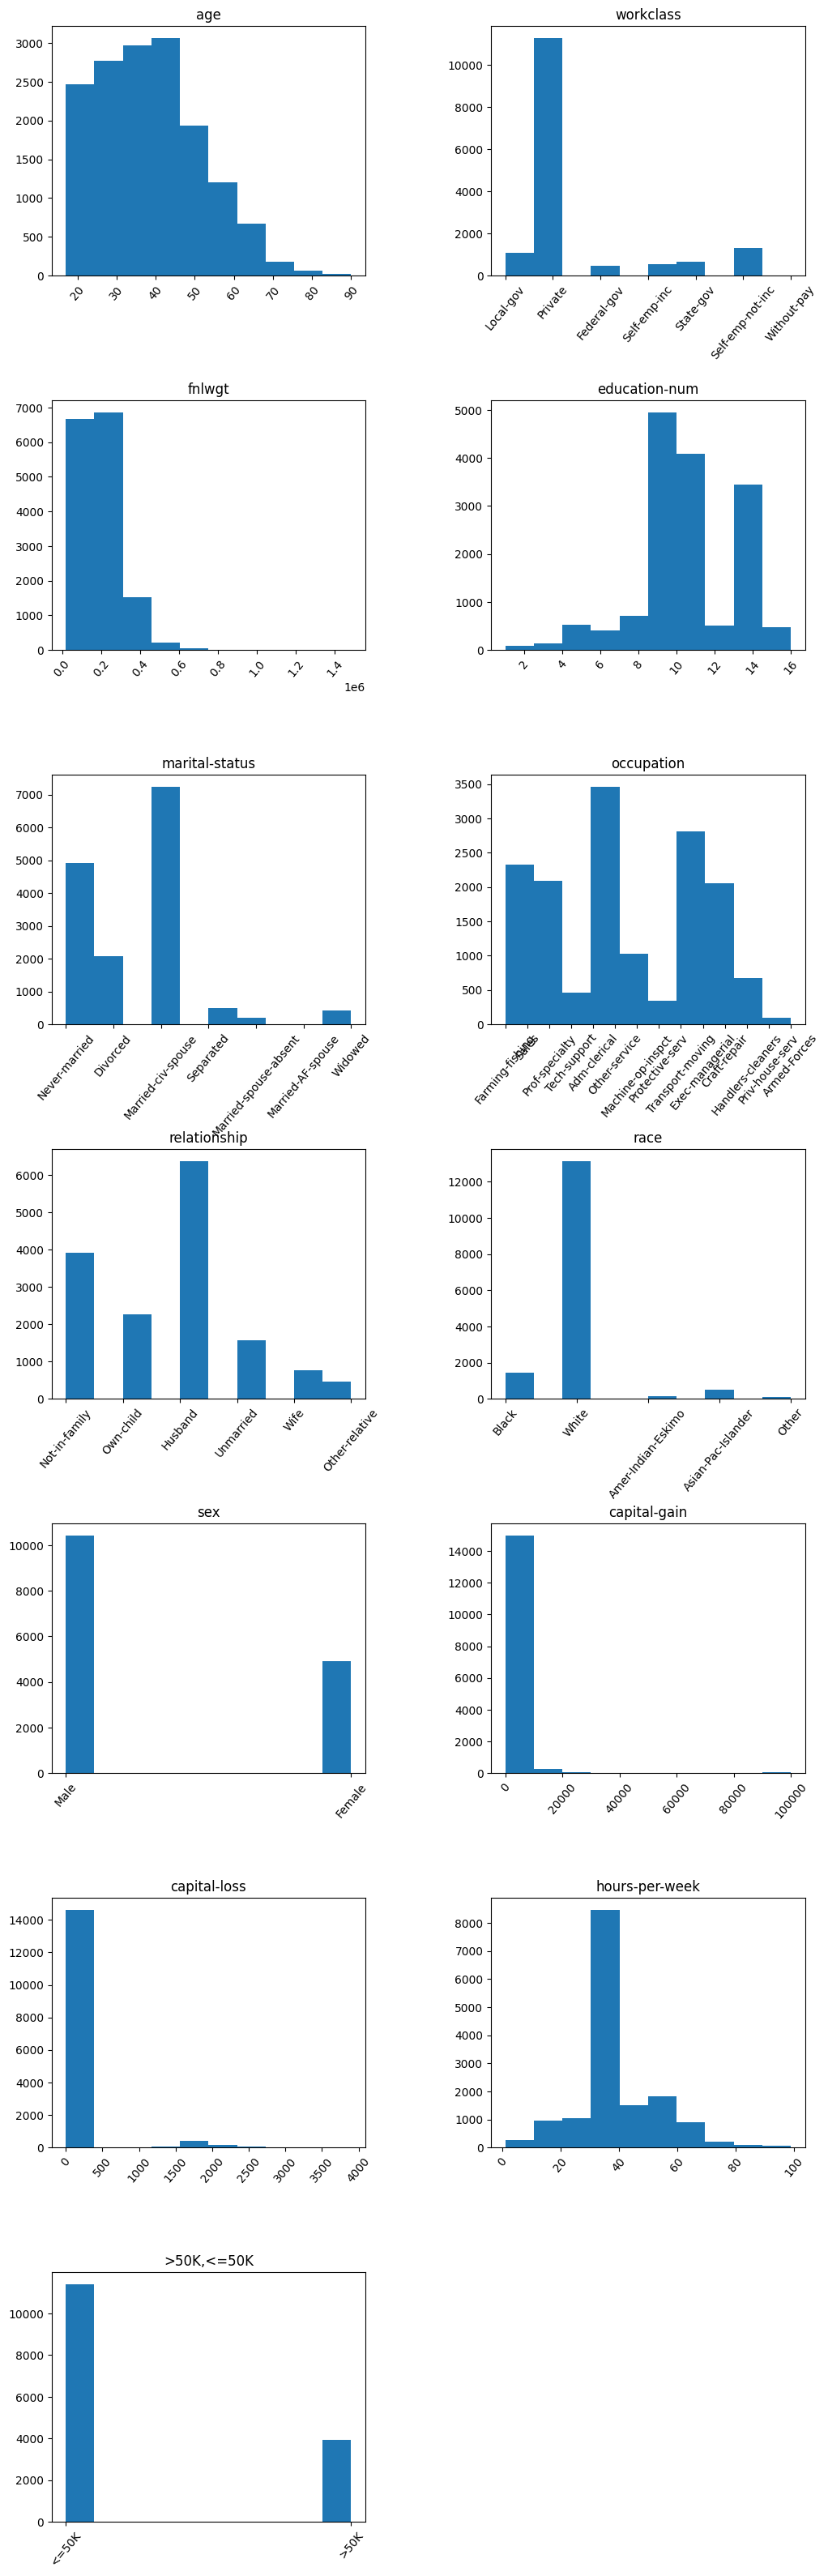

In [215]:
i = 1
cols = int(round(data.shape[1]/2+0.1))
plt.figure(figsize=(12, 40))

for column in data.columns:
    plt.subplot(cols, 2, i)
    plt.subplots_adjust(wspace=0.4, hspace=0.5)
    plt.xticks(rotation=50)
    plt.hist(data[column])
    plt.title(column)
    i+=1


**Целевой признак несбалансирован и имеет отношение примерно 1/3.**
**Ни один из признаков не распределен равномерно. Многие из них имеют выбросы/аномальные значения, как например 100000 в capital_gain.**
**Т.к. деревья устойчивы к выбросам, то было решено ничего с ними не делать.**

## Добавление категориальных признаков

Добавим к предобработанным вещественным признакам категориальные. Но для начала их тоже необходимо предобработать.

Преобразуйте все категориальные признаки с помощью метода one-hot-encoding (например, это можно сделать с помощью функции [pandas.get_dummies](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html) или [DictVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.DictVectorizer.html) / [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) из sklearn).

После преобразования категориальных признаков, добавьте их к вещественным предобработанным данным для обучения.

>PS Напоминаю, что важно удалить колонку с целевым значением

In [216]:
cat_columns = []
for column in X_train.columns:
    if X_train[column].dtype == 'O':
        cat_columns.append(column)
cat_columns

['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']

In [217]:
gd_data = pd.get_dummies(X_train[cat_columns],  dtype=int)
X_train_dummies = X_train.drop(cat_columns, axis=1).join(gd_data)
X_train_dummies

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
7468,42,178780,14,0,0,50,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
7518,54,187686,10,0,0,38,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
13163,62,177791,6,0,0,40,0,0,1,0,...,1,0,0,0,0,0,0,1,1,0
544,35,112160,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1
13288,19,196119,9,0,0,35,0,0,1,0,...,1,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,38,341643,12,0,0,60,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
14257,22,215546,12,0,0,55,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1
5736,31,185732,9,0,0,30,0,0,1,0,...,1,0,0,0,0,0,0,1,1,0
914,54,54377,14,0,0,40,0,1,0,0,...,0,0,0,0,0,0,0,1,1,0


In [218]:
gd_test_data = pd.get_dummies(X_test[cat_columns],  dtype=int)
X_test_dummies = X_test.drop(cat_columns, axis=1).join(gd_test_data)

## Обучение классификаторов

В начале посмотрим, как работает подбор параметров по сетке и как влияет на качество разбиение выборки. Сейчас и далее будем рассматривать 2 алгоритма:
 - [DecisonTree](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)
 - [RandomForest](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

Для начала обучим  выберем один гиперпараметр, который будем оптимизировать, — глубина дерева (*max_depth*).
 
Остальные параметры оставляйте в значениях по умолчанию.

Для каждого алгоритма подберите оптимальные значения указанных гиперпараметров. Постройте график среднего значения качества по кросс-валидации алгоритма при заданном значении гиперпараметра, на котором также отобразите доверительный интервал.

Что вы можете сказать о получившихся графиках? Какой алгоритм справился лучше? Какой быстрее? Почему?

In [219]:
parameters = {'max_depth':[2,5,8,10,12,15,20]}

tree = DecisionTreeClassifier()
gsCV = GridSearchCV(tree, parameters)
gsCV.fit(X_train_dummies, y_train)
tree_results = gsCV.cv_results_

forest = RandomForestClassifier()
gsCV = GridSearchCV(forest, parameters)
gsCV.fit(X_train_dummies, y_train)
forest_results = gsCV.cv_results_

In [220]:
tree_results

{'mean_fit_time': array([0.02789063, 0.04554901, 0.05698309, 0.07183652, 0.07323976,
        0.08520422, 0.09034262]),
 'std_fit_time': array([0.00398275, 0.00464563, 0.00355539, 0.00950959, 0.01326512,
        0.01519557, 0.01780076]),
 'mean_score_time': array([0.00541964, 0.00562186, 0.00421877, 0.00501823, 0.00481896,
        0.00468426, 0.00488205]),
 'std_score_time': array([0.0008037 , 0.00120277, 0.0004026 , 0.00063347, 0.00075044,
        0.0004901 , 0.00148446]),
 'param_max_depth': masked_array(data=[2, 5, 8, 10, 12, 15, 20],
              mask=[False, False, False, False, False, False, False],
        fill_value=999999),
 'params': [{'max_depth': 2},
  {'max_depth': 5},
  {'max_depth': 8},
  {'max_depth': 10},
  {'max_depth': 12},
  {'max_depth': 15},
  {'max_depth': 20}],
 'split0_test_score': array([0.82519001, 0.84364821, 0.84093377, 0.84147666, 0.834962  ,
        0.82247557, 0.80998914]),
 'split1_test_score': array([0.81541802, 0.8393051 , 0.8393051 , 0.834962  , 0.82

In [221]:
forest_results

{'mean_fit_time': array([0.50416894, 0.68640361, 0.86893172, 1.0437036 , 1.06744413,
        1.24116106, 1.35641298]),
 'std_fit_time': array([0.02582532, 0.04450081, 0.05140765, 0.03928493, 0.02604045,
        0.05817992, 0.06732218]),
 'mean_score_time': array([0.01995564, 0.02256861, 0.03371272, 0.04259882, 0.04309349,
        0.04894395, 0.06886535]),
 'std_score_time': array([0.00427156, 0.00340077, 0.00826375, 0.00967583, 0.00979434,
        0.00478043, 0.00722655]),
 'param_max_depth': masked_array(data=[2, 5, 8, 10, 12, 15, 20],
              mask=[False, False, False, False, False, False, False],
        fill_value=999999),
 'params': [{'max_depth': 2},
  {'max_depth': 5},
  {'max_depth': 8},
  {'max_depth': 10},
  {'max_depth': 12},
  {'max_depth': 15},
  {'max_depth': 20}],
 'split0_test_score': array([0.76655809, 0.84147666, 0.85450597, 0.85884908, 0.85667752,
        0.85830619, 0.85124864]),
 'split1_test_score': array([0.7795874 , 0.834962  , 0.84799131, 0.85070575, 0.85

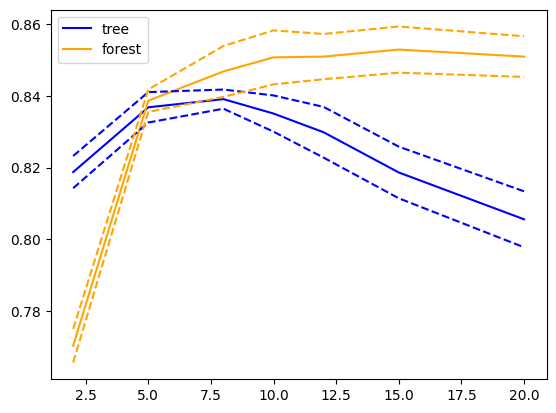

In [222]:
plt.plot([2,5,8,10,12,15,20], tree_results['mean_test_score'], c='blue')
plt.plot([2,5,8,10,12,15,20], forest_results['mean_test_score'], c='orange')

plt.plot([2,5,8,10,12,15,20], tree_results['mean_test_score']+tree_results['std_test_score'], 'b--')
plt.plot([2,5,8,10,12,15,20], tree_results['mean_test_score']-tree_results['std_test_score'], 'b--')

plt.plot([2,5,8,10,12,15,20], forest_results['mean_test_score']+forest_results['std_test_score'], '--', c='orange')
plt.plot([2,5,8,10,12,15,20], forest_results['mean_test_score']-forest_results['std_test_score'], '--', c='orange')
plt.legend(['tree', 'forest'])


**Лучше справился алгоритм случайного леса по причине рассмотрения большего количества деревьев. Быстрее справился алгоритм дерева решений, потому что алгоритм случайного леса имеет по умолчанию n_estimators=100 - количество деревьев**
**У дерева решений наилучшая глубина находится около 8. У случайного леса наилучшая глубина около 15, однако при 20 качество не начало резко ухудшаться, как в дереве решений, поэтому следует рассмотреть глубину около 20**

Далее произведем подбор других гиперпараметров алгоритмов. Начнет со случайного леса. Для начала подберём число деревьев (*n_estimators*) в алгоритме RandomForest. Как известно, в общем случае Random Forest не переобучается с увеличением количества деревьев. Подберите количество деревьев, начиная с которого качество на кросс-валидации стабилизируется. Обратите внимание, что для проведения этого эксперимента не нужно с нуля обучать много случайных лесов с различными количествами деревьев. Обучите один случайный лес с максимальным интересным количеством деревьев, а затем рассмотрите подмножества деревьев разных размеров, состоящих из деревьев построенного леса (поле [*estimators_*](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)). В дальнейших экспериментах используйте подобранное количество деревьев.

In [256]:
[1,2,3][:2]

[1, 2]

In [257]:
forest = RandomForestClassifier(n_estimators=500, random_state = 42)
forest.fit(X_train_dummies, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

In [273]:
estimators = forest.estimators_

n_estimators_list = []
score_list = []

for i in range(2, 500, 20):
    subforest = RandomForestClassifier(n_estimators=i)
    subforest.estimators_ = estimators[:i]
    score = cross_val_score(subforest, X_train_dummies, y_train).mean()
    n_estimators_list.append(i)
    score_list.append(score)
    print(i, end=' ')

2 22 42 62 82 102 122 142 162 182 202 222 242 262 282 302 322 342 362 382 402 422 442 462 482 

Text(0.5, 1.0, 'score от n_estimators')

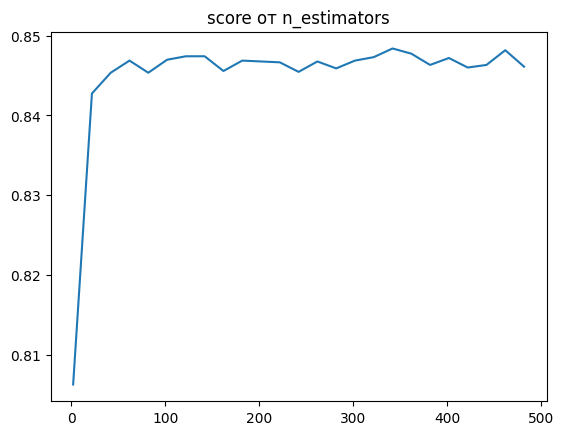

In [274]:
plt.plot(n_estimators_list, score_list)
plt.title('score от n_estimators')

In [279]:
best_estimator = n_estimators_list[np.argmax(score_list)]

Теперь подберите следующие оптимальные параметры:
- максимальная глубина решающего дерева (*max_depth*)
- функция оценки качества разбиения (*criterion*)
- максимальное количесво учитываемых признаков при разбиении (*max_features*)

Остальные параметры оставляйте по умолчанию, за исключением парамтра `n_estimators` для случайного леса, выбранного на предыдущем шаге.

Оцените скорость обучения каждого из алгоритмов. Для этого воспользуйтесь графиком вида "ящик с усами", который отражает среднее время обучения алгоритма при фиксированном значении гиперпараметров. Что вы можете сказать о скорости работы алгоритмов? Почему наблюдаются такие результаты? Можно ли ускорить? Если да, то каким образом?

In [280]:
parameters = {'max_depth':(4,5,6,7,8,9,10), 'criterion':('gini', 'entropy', 'log_loss'), 'max_features':('sqrt', 'log2', None)}

tree = DecisionTreeClassifier()
gsCV = GridSearchCV(tree, parameters)
gsCV.fit(X_train_dummies, y_train)
tree_results = gsCV.cv_results_

parameters = {'max_depth':(8,10,12,15,20,22,24), 'criterion':('gini', 'entropy', 'log_loss'), 'max_features':('sqrt', 'log2', None)}

forest = RandomForestClassifier(n_estimators=best_estimator)
gsCV = GridSearchCV(forest, parameters)
gsCV.fit(X_train_dummies, y_train)
forest_results = gsCV.cv_results_

Text(0.5, 1.0, 'Forest fit time')

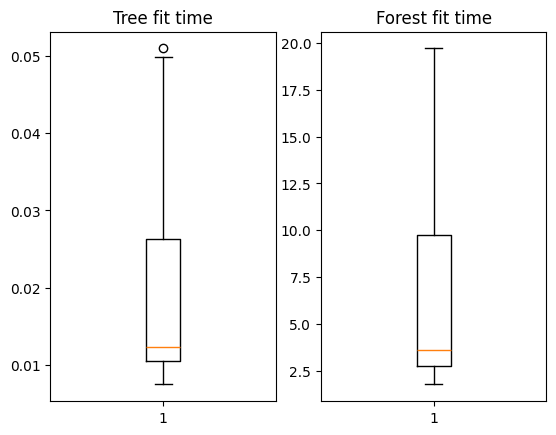

In [294]:
plt.subplot(1,2,1)
plt.boxplot(tree_results['mean_fit_time'])
plt.title('Tree fit time')

plt.subplot(1,2,2)
plt.boxplot(forest_results['mean_fit_time'])
plt.title('Forest fit time')

**Время обучения дерева решений на порядок быстрее времени обучения случайного леса. Это объясняется ансамблем моделей деревьев в случайном лесу. Ускорить можно изменив гиперпараметры леса, например, количество деревьев или максимальную глубину. В то же время можно воспользоваться гиперпараметром n_jobs для параллельного обучения. Например:**

In [304]:
gsCV.best_params_.values()

dict_values(['entropy', 15, 'log2'])

In [313]:
import time

testing = RandomForestClassifier(n_estimators=best_estimator, criterion='entropy', max_depth=15, max_features='log2', n_jobs=-1)

start_time = time.time()
testing.fit(X_train_dummies, y_train) 
end_time = time.time()

end_time - start_time

1.3214442729949951

**Результат получился, грубо говоря, в 3 раза быстрее среднего по кросс валидации выше**

## Сравнение результатов

Сравните результаты алгоритмво. Для этого воспользуйтесь "ящиком с усами" (boxplot).

Сделайте общие итоговые выводы о классификаторах с точки зрения их работы с признаками и сложности самой модели (какие гиперпараметры есть у модели, сильно ли изменение значения гиперпараметра влияет на качество модели).

Text(0.5, 1.0, 'Forest scores')

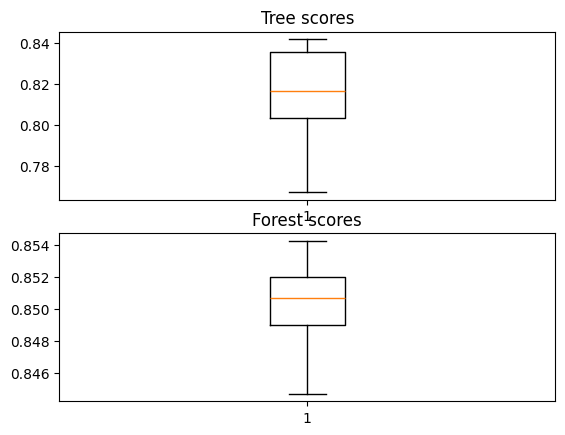

In [296]:
plt.subplot(2,1,1)
plt.boxplot(tree_results['mean_test_score'])
plt.title('Tree scores')

plt.subplot(2,1,2)
plt.boxplot(forest_results['mean_test_score'])
plt.title('Forest scores')

**По графикам можно заметить, что у случайного леса и в среднем, и по разбросу, лучше результаты, чем у дерева решений. Такое вполне можно было ожидать из-за сложности самой модели. Влияние гиперпараметров на дерево решений можно заметить по разбросу: от ~0.77 до 0.84. В случайном лесе разброс на порядок меньше: от ~0.845 до 0.854. Это может быть объяснено тем, что количество деревьев в лесу мы перебирали отдельно ранее, в том числе была изменена максимальная глубина для перебора: ближе к максимальному результату, основываясь на первом переборе max_depth. Вероятнее всего разброс результатов дерева решений мог быть еще больше по той же причине, что и у случайного леса - разброс перебора максимальной глубины был уменьшен.**

## Тестирование всех модели

Протестируйте последние построенные модели (наилучшее решающее дерево и наилучший случайный лес) на данных, которые были отложены для теста (их должно было остаться 40%). Не забудьте про все необходимые преобразования.

**Все необходимые преобразования проводились параллельно с преобразованиями над тренировочными данными.**

In [352]:
final_forest = RandomForestClassifier(best_estimator, criterion='entropy', max_depth=15, max_features='log2')
final_forest.fit(X_train_dummies, y_train)
y_pred_forest = final_forest.predict(X_test_dummies)
f1_score(y_test, y_pred_forest)

0.6809611829944547

In [344]:
tree_results['params'][np.argwhere(tree_results['rank_test_score']==1)[0][0]]

{'criterion': 'entropy', 'max_depth': 8, 'max_features': None}

In [353]:
final_tree = DecisionTreeClassifier(criterion='entropy', max_depth=8, max_features=None)
final_tree.fit(X_train_dummies, y_train)
y_pred_tree = final_tree.predict(X_test_dummies)
f1_score(y_test, y_pred_tree)

0.6319042101197373

In [359]:
print('tree','\n',classification_report(y_test, y_pred_tree))
print('forest','\n',classification_report(y_test, y_pred_forest))

tree 
               precision    recall  f1-score   support

           0       0.85      0.95      0.90      4577
           1       0.80      0.52      0.63      1562

    accuracy                           0.84      6139
   macro avg       0.83      0.74      0.77      6139
weighted avg       0.84      0.84      0.83      6139

forest 
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      4577
           1       0.81      0.59      0.68      1562

    accuracy                           0.86      6139
   macro avg       0.84      0.77      0.80      6139
weighted avg       0.85      0.86      0.85      6139

